# Neural Dynamic Models for the Unbalanced Disk

This notebook contains the two retained neural modelling approaches:

1. Neural Output-Error (NOE) model.
2. Benchmark-aligned encoder RNN.

All preserved training outputs correspond to the original completed runs.

In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import copy
import time
import torch
import numpy as np
from torch import nn
from matplotlib import pyplot as plt
import pandas as pd

# Keep all relative data, checkpoint, graph, and submission paths anchored
# to the original project directory.
PROJECT_DIR = (
    r"C:\Users\Vasil\5SC28 MACHINE LEARNING"
    r"\ML-for-control-systems-Pendulum-NOE-kostas"
)
os.chdir(PROJECT_DIR)
print("Working directory:", os.getcwd())


Working directory: C:\Users\Vasil\5SC28 MACHINE LEARNING\ML-for-control-systems-Pendulum-NOE-kostas


# 1. Neural Output-Error (NOE) Model

The NOE model uses delayed inputs and recursively generated outputs. The
completed hyperparameter sweep, selected checkpoints, and validation results
are preserved below without rerunning or modifying the original training.

## 1.1 Data loading and inspection

u shape: (35000,)
th shape: (35000,)


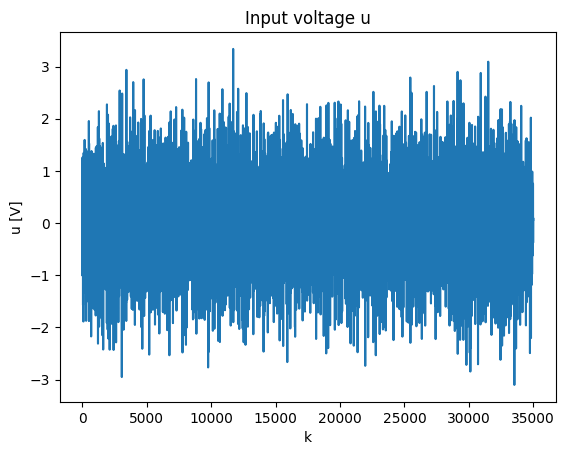

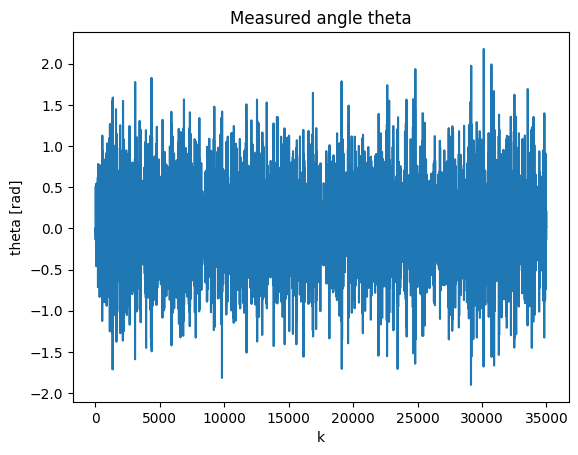

In [3]:
out = np.load("training-val-test-data.npz")

th = out["th"]   # measured disk angle
u = out["u"]     # applied input voltage

print("u shape:", u.shape)
print("th shape:", th.shape)

plt.figure()
plt.plot(u)
plt.title("Input voltage u")
plt.xlabel("k")
plt.ylabel("u [V]")
plt.show()

plt.figure()
plt.plot(th)
plt.title("Measured angle theta")
plt.xlabel("k")
plt.ylabel("theta [rad]")
plt.show()

## 1.2 Chronological training-validation-test split

In [4]:
N = len(u)

N_train = int(0.7 * N)
N_val = int(0.15 * N)

u_train = u[:N_train]
th_train = th[:N_train]

u_val = u[N_train:N_train + N_val]
th_val = th[N_train:N_train + N_val]

u_test = u[N_train + N_val:]
th_test = th[N_train + N_val:]

print(len(u_train), len(u_val), len(u_test))

24500 5250 5250


## 1.3 Normalization using training statistics

In [5]:
u_mean = u_train.mean()
u_std = u_train.std()

th_mean = th_train.mean()
th_std = th_train.std()

u_train_n = (u_train - u_mean) / u_std
u_val_n = (u_val - u_mean) / u_std
u_test_n = (u_test - u_mean) / u_std

th_train_n = (th_train - th_mean) / th_std
th_val_n = (th_val - th_mean) / th_std
th_test_n = (th_test - th_mean) / th_std

print("u mean/std:", u_mean, u_std)
print("theta mean/std:", th_mean, th_std)

u mean/std: -2.687187240524085e-05 0.8410479397424789
theta mean/std: 0.03394048474666838 0.46785269160434234


## 1.4 NOE data windows and model definition

In [6]:
def make_OE_data(udata, ydata, nf=100):
    U = [] 
    Y = [] 
    for k in range(nf, len(udata) + 1):
        U.append(udata[k-nf:k])
        Y.append(ydata[k-nf:k])
    return np.array(U), np.array(Y)

In [7]:
class NOENet(nn.Module):
    def __init__(self, na=5, nb=5, hidden_size=64):
        super().__init__()

        self.na = na
        self.nb = nb
        self.n0 = max(na, nb)

        input_size = na + nb

        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, U_seq, Y_seq):
        """
        U_seq: shape (batch, sequence_length)
        Y_seq: shape (batch, sequence_length)

        We use the first n0 true outputs only for initialization.
        After that, the model recursively feeds back its own predictions.
        """

        batch_size, seq_len = U_seq.shape

        # first n0 samples are used as initial conditions
        y_generated = []
        for i in range(self.n0):
            y_generated.append(Y_seq[:, i])

        # recursive simulation
        for t in range(self.n0, seq_len):
            u_lags = U_seq[:, t-self.nb:t]
            y_lags = torch.stack(y_generated[t-self.na:t], dim=1)

            x = torch.cat([u_lags, y_lags], dim=1)

            y_next = self.net(x).squeeze(1)
            y_generated.append(y_next)

        Y_hat = torch.stack(y_generated, dim=1)

        return Y_hat

## 1.5 Training and evaluation functions

In [8]:
def train_noe(model, train_loader, U_val_t, Y_val_t, epochs=100, lr=1e-3, weight_decay=1e-6):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=25,
        min_lr=1e-5
    )

    loss_fn = nn.MSELoss()

    train_losses = []
    val_losses = []

    best_val_loss = np.inf
    best_state = None

    for epoch in range(epochs):
        model.train()
        batch_losses = []

        for U_batch, Y_batch in train_loader:
            optimizer.zero_grad()

            Y_hat = model(U_batch, Y_batch)

            loss = loss_fn(Y_hat[:, model.n0:], Y_batch[:, model.n0:])

            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            batch_losses.append(loss.item())

        train_loss = np.mean(batch_losses)

        model.eval()
        with torch.no_grad():
            Y_val_hat = model(U_val_t, Y_val_t)
            val_loss = loss_fn(Y_val_hat[:, model.n0:], Y_val_t[:, model.n0:]).item()

        # Put it here
        scheduler.step(val_loss)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())

        if epoch % 10 == 0:
            current_lr = optimizer.param_groups[0]["lr"]
            print(
                f"Epoch {epoch:4d} | "
                f"train sim loss = {train_loss:.6f} | "
                f"val sim loss = {val_loss:.6f} | "
                f"lr = {current_lr:.2e}"
            )

    model.load_state_dict(best_state)

    return train_losses, val_losses

In [9]:
def simulate_noe_full(model, u_seq, y_seq, th_mean, th_std):
    model.eval()

    u_t = torch.tensor(u_seq, dtype=torch.float32)
    y_t = torch.tensor(y_seq, dtype=torch.float32)

    N = len(u_t)
    n0 = model.n0
    na = model.na
    nb = model.nb

    y_generated = []

    for i in range(n0):
        y_generated.append(y_t[i])

    with torch.no_grad():
        for t in range(n0, N):
            u_lags = u_t[t-nb:t].reshape(1, -1)
            y_lags = torch.stack(y_generated[t-na:t]).reshape(1, -1)

            # Safety check while debugging
            assert u_lags.shape[1] == nb, f"u_lags has {u_lags.shape[1]} values, expected {nb}"
            assert y_lags.shape[1] == na, f"y_lags has {y_lags.shape[1]} values, expected {na}"

            x = torch.cat([u_lags, y_lags], dim=1)

            assert x.shape[1] == na + nb, f"x has {x.shape[1]} values, expected {na + nb}"

            if hasattr(model, "predict_from_lags"):
                y_next = model.predict_from_lags(x).squeeze()
            else:
                y_next = model.net(x).squeeze()

            y_generated.append(y_next)

    y_hat_n = torch.stack(y_generated).numpy()

    y_hat = y_hat_n * th_std + th_mean
    y_true = y_seq * th_std + th_mean

    return y_hat, y_true

In [10]:
def evaluate_noe_full(model, u_val_n, th_val_n, th_mean, th_std):
    th_val_sim, th_val_true = simulate_noe_full(
        model,
        u_val_n,
        th_val_n,
        th_mean,
        th_std
    )

    skip = model.n0

    rms = np.sqrt(np.mean((th_val_sim[skip:] - th_val_true[skip:])**2))
    rms_deg = rms / (2*np.pi) * 360
    nrms = rms / np.std(th_val_true[skip:])

    return rms, rms_deg, nrms * 100, th_val_sim, th_val_true

In [11]:
def one_step_prediction_noe(model, u_seq, y_seq, th_mean, th_std):
    model.eval()

    u_t = torch.tensor(u_seq, dtype=torch.float32)
    y_t = torch.tensor(y_seq, dtype=torch.float32)

    N = len(u_t)
    n0 = model.n0
    na = model.na
    nb = model.nb

    y_pred = []

    for i in range(n0):
        y_pred.append(y_t[i])

    with torch.no_grad():
        for t in range(n0, N):
            u_lags = u_t[t-nb:t].reshape(1, -1)
            y_lags = y_t[t-na:t].reshape(1, -1)

            x = torch.cat([u_lags, y_lags], dim=1)

            if hasattr(model, "predict_from_lags"):
                y_next = model.predict_from_lags(x).squeeze()
            else:
                y_next = model.net(x).squeeze()

            y_pred.append(y_next)

    y_pred_n = torch.stack(y_pred).numpy()

    y_pred_denorm = y_pred_n * th_std + th_mean
    y_true_denorm = y_seq * th_std + th_mean

    return y_pred_denorm, y_true_denorm

## 1.6 Hyperparameter tuning and model selection

The preserved sweep compares recursive rollout length, lag orders, hidden
size, learning rate, and regularization. The additional trade-off diagram is
placed directly after the tuning summary so that it supports the selection
decision without interrupting the final validation results.

In [12]:
seed = 12

noe_configs = [
    # Shorter rollout, compact memory
    {"nfuture": 50, "na": 3, "nb": 3, "hidden_size": 24, "lr": 3e-4, "weight_decay": 1e-6, "epochs": 400},
    {"nfuture": 50, "na": 4, "nb": 3, "hidden_size": 32, "lr": 3e-4, "weight_decay": 1e-6, "epochs": 400},
    {"nfuture": 50, "na": 5, "nb": 4, "hidden_size": 32, "lr": 3e-4, "weight_decay": 1e-6, "epochs": 400},

    # Medium rollout, varied model orders
    {"nfuture": 60, "na": 4, "nb": 4, "hidden_size": 32, "lr": 3e-4, "weight_decay": 1e-6, "epochs": 500},
    {"nfuture": 60, "na": 5, "nb": 3, "hidden_size": 32, "lr": 3e-4, "weight_decay": 1e-6, "epochs": 500},
    {"nfuture": 60, "na": 6, "nb": 4, "hidden_size": 48, "lr": 3e-4, "weight_decay": 1e-6, "epochs": 500},

    # Longer rollout, candidate stable simulators
    {"nfuture": 70, "na": 4, "nb": 4, "hidden_size": 32, "lr": 3e-4, "weight_decay": 1e-6, "epochs": 500},
    {"nfuture": 70, "na": 5, "nb": 4, "hidden_size": 32, "lr": 3e-4, "weight_decay": 1e-6, "epochs": 500},
    {"nfuture": 70, "na": 5, "nb": 5, "hidden_size": 32, "lr": 3e-4, "weight_decay": 1e-6, "epochs": 500},
    {"nfuture": 70, "na": 6, "nb": 4, "hidden_size": 32, "lr": 3e-4, "weight_decay": 1e-6, "epochs": 500},

    # Even longer rollout, lower capacity / regularization check
    {"nfuture": 80, "na": 4, "nb": 3, "hidden_size": 32, "lr": 3e-4, "weight_decay": 1e-6, "epochs": 500},
    {"nfuture": 80, "na": 5, "nb": 4, "hidden_size": 32, "lr": 3e-4, "weight_decay": 1e-6, "epochs": 500},
    {"nfuture": 80, "na": 6, "nb": 4, "hidden_size": 48, "lr": 3e-4, "weight_decay": 1e-5, "epochs": 500},

    # Learning-rate / regularization variants
    {"nfuture": 70, "na": 5, "nb": 4, "hidden_size": 32, "lr": 1e-4, "weight_decay": 1e-6, "epochs": 600},
    {"nfuture": 70, "na": 5, "nb": 4, "hidden_size": 32, "lr": 3e-4, "weight_decay": 1e-5, "epochs": 500},
]
noe_results = []

best_noe_rmse = np.inf
best_noe_model = None
best_noe_config = None
best_noe_losses = None
best_noe_sim = None
best_noe_true = None

for cfg in noe_configs:
    print("\n====================================")
    print("Training NOE config:", cfg)
    print("====================================")

    np.random.seed(seed)
    torch.manual_seed(seed)

    nfuture = cfg["nfuture"]

    U_train, Y_train = make_OE_data(u_train_n, th_train_n, nf=nfuture)
    U_val, Y_val = make_OE_data(u_val_n, th_val_n, nf=nfuture)

    U_train_t = torch.tensor(U_train, dtype=torch.float32)
    Y_train_t = torch.tensor(Y_train, dtype=torch.float32)
    U_val_t = torch.tensor(U_val, dtype=torch.float32)
    Y_val_t = torch.tensor(Y_val, dtype=torch.float32)

    train_dataset = TensorDataset(U_train_t, Y_train_t)
    train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

    model = NOENet(
        na=cfg["na"],
        nb=cfg["nb"],
        hidden_size=cfg["hidden_size"]
    )

    train_losses_tmp, val_losses_tmp = train_noe(
        model,
        train_loader,
        U_val_t,
        Y_val_t,
        epochs=cfg["epochs"],
        lr=cfg["lr"],
        weight_decay=cfg["weight_decay"]
    )

    rms, rms_deg, nrms_percent, th_val_sim_tmp, th_val_true_tmp = evaluate_noe_full(
        model,
        u_val_n,
        th_val_n,
        th_mean,
        th_std
    )

    # One-step prediction metric
    th_val_pred_tmp, th_val_true_pred_tmp = one_step_prediction_noe(
        model,
        u_val_n,
        th_val_n,
        th_mean,
        th_std
    )

    skip = model.n0

    pred_rms = np.sqrt(
        np.mean((th_val_pred_tmp[skip:] - th_val_true_pred_tmp[skip:])**2)
    )
    pred_rms_deg = pred_rms / (2 * np.pi) * 360
    pred_nrms_percent = pred_rms / np.std(th_val_true_pred_tmp[skip:]) * 100

    combined_score = pred_rms / 0.00665 + rms / 0.0271

    result = {
        "nfuture": cfg["nfuture"],
        "na": cfg["na"],
        "nb": cfg["nb"],
        "hidden_size": cfg["hidden_size"],
        "lr": cfg["lr"],
        "weight_decay": cfg["weight_decay"],
        "epochs": cfg["epochs"],

        "prediction_rmse_rad": pred_rms,
        "prediction_rmse_deg": pred_rms_deg,
        "prediction_nrms_percent": pred_nrms_percent,

        "simulation_rmse_rad": rms,
        "simulation_rmse_deg": rms_deg,
        "simulation_nrms_percent": nrms_percent,

        "combined_score": combined_score,

        "best_window_val_loss": np.min(val_losses_tmp),
        "best_epoch": int(np.argmin(val_losses_tmp))
    }

    noe_results.append(result)

    print("One-step prediction RMSE:", pred_rms, "rad")
    print("One-step prediction NRMS:", pred_nrms_percent, "%")
    print("Full validation simulation RMSE:", rms, "rad")
    print("Full validation simulation NRMS:", nrms_percent, "%")
    print("Combined score:", combined_score)


Training NOE config: {'nfuture': 50, 'na': 3, 'nb': 3, 'hidden_size': 24, 'lr': 0.0003, 'weight_decay': 1e-06, 'epochs': 400}
Epoch    0 | train sim loss = 0.946473 | val sim loss = 1.013393 | lr = 3.00e-04
Epoch   10 | train sim loss = 0.550910 | val sim loss = 0.612268 | lr = 3.00e-04
Epoch   20 | train sim loss = 0.024200 | val sim loss = 0.037853 | lr = 3.00e-04
Epoch   30 | train sim loss = 0.011890 | val sim loss = 0.021823 | lr = 3.00e-04
Epoch   40 | train sim loss = 0.009008 | val sim loss = 0.017018 | lr = 3.00e-04
Epoch   50 | train sim loss = 0.007880 | val sim loss = 0.015797 | lr = 3.00e-04
Epoch   60 | train sim loss = 0.007229 | val sim loss = 0.014305 | lr = 3.00e-04
Epoch   70 | train sim loss = 0.006593 | val sim loss = 0.013509 | lr = 3.00e-04
Epoch   80 | train sim loss = 0.006367 | val sim loss = 0.013350 | lr = 3.00e-04
Epoch   90 | train sim loss = 0.005917 | val sim loss = 0.013390 | lr = 3.00e-04
Epoch  100 | train sim loss = 0.005561 | val sim loss = 0.01184

In [13]:
noe_results_df = pd.DataFrame(noe_results)

# Clean results table
results_table = noe_results_df.copy()

# Sort by combined score
results_table = results_table.sort_values("combined_score").reset_index(drop=True)

# Select useful columns
cols = [
    "nfuture",
    "na",
    "nb",
    "hidden_size",
    "lr",
    "weight_decay",
    "epochs",
    "prediction_rmse_rad",
    "simulation_rmse_rad",
    "combined_score",
]

results_table = results_table[cols]

# Optional: round for readability
display_table = results_table.copy()
display_table["lr"] = display_table["lr"].map(lambda x: f"{x:.0e}")
display_table["weight_decay"] = display_table["weight_decay"].map(lambda x: f"{x:.0e}")
display_table["prediction_rmse_rad"] = display_table["prediction_rmse_rad"].round(5)
display_table["simulation_rmse_rad"] = display_table["simulation_rmse_rad"].round(5)
display_table["combined_score"] = display_table["combined_score"].round(3)

display(display_table)

# Best models according to different criteria
best_prediction = noe_results_df.loc[noe_results_df["prediction_rmse_rad"].idxmin()]
best_simulation = noe_results_df.loc[noe_results_df["simulation_rmse_rad"].idxmin()]
best_combined = noe_results_df.loc[noe_results_df["combined_score"].idxmin()]

print("\nBest one-step prediction model")
print("--------------------------------")
print(
    f"Config: nfuture={best_prediction['nfuture']}, "
    f"na={best_prediction['na']}, nb={best_prediction['nb']}, "
    f"hidden_size={best_prediction['hidden_size']}, "
    f"lr={best_prediction['lr']}, "
    f"weight_decay={best_prediction['weight_decay']}, "
    f"epochs={best_prediction['epochs']}"
)
print(f"Prediction RMSE: {best_prediction['prediction_rmse_rad']:.6f} rad")
print(f"Simulation RMSE: {best_prediction['simulation_rmse_rad']:.6f} rad")
print(f"Combined score: {best_prediction['combined_score']:.3f}")

print("\nBest full simulation model")
print("--------------------------------")
print(
    f"Config: nfuture={best_simulation['nfuture']}, "
    f"na={best_simulation['na']}, nb={best_simulation['nb']}, "
    f"hidden_size={best_simulation['hidden_size']}, "
    f"lr={best_simulation['lr']}, "
    f"weight_decay={best_simulation['weight_decay']}, "
    f"epochs={best_simulation['epochs']}"
)
print(f"Prediction RMSE: {best_simulation['prediction_rmse_rad']:.6f} rad")
print(f"Simulation RMSE: {best_simulation['simulation_rmse_rad']:.6f} rad")
print(f"Combined score: {best_simulation['combined_score']:.3f}")

print("\nBest combined model")
print("--------------------------------")
print(
    f"Config: nfuture={best_combined['nfuture']}, "
    f"na={best_combined['na']}, nb={best_combined['nb']}, "
    f"hidden_size={best_combined['hidden_size']}, "
    f"lr={best_combined['lr']}, "
    f"weight_decay={best_combined['weight_decay']}, "
    f"epochs={best_combined['epochs']}"
)
print(f"Prediction RMSE: {best_combined['prediction_rmse_rad']:.6f} rad")
print(f"Simulation RMSE: {best_combined['simulation_rmse_rad']:.6f} rad")
print(f"Combined score: {best_combined['combined_score']:.3f}")

,nfuture,na,nb,hidden_size,lr,weight_decay,epochs,prediction_rmse_rad,simulation_rmse_rad,combined_score
0,70,5,4,32,3e-04,1e-06,500,0.00624,0.02249,1.768
1,50,4,3,32,3e-04,1e-06,400,0.00430,0.03058,1.775
2,70,5,4,32,3e-04,1e-05,500,0.00623,0.02315,1.792
3,50,5,4,32,3e-04,1e-06,400,0.00634,0.02908,2.026
4,80,5,4,32,3e-04,1e-06,500,0.00676,0.02806,2.052
5,80,4,3,32,3e-04,1e-06,500,0.00579,0.03292,2.086
6,70,6,4,32,3e-04,1e-06,500,0.00748,0.02736,2.135
7,60,6,4,48,3e-04,1e-06,500,0.00690,0.02990,2.141
8,70,5,4,32,1e-04,1e-06,600,0.00756,0.02976,2.235
9,60,4,4,32,3e-04,1e-06,500,0.00512,0.04057,2.267



Best one-step prediction model
--------------------------------
Config: nfuture=50.0, na=4.0, nb=3.0, hidden_size=32.0, lr=0.0003, weight_decay=1e-06, epochs=400.0
Prediction RMSE: 0.004300 rad
Simulation RMSE: 0.030581 rad
Combined score: 1.775

Best full simulation model
--------------------------------
Config: nfuture=70.0, na=5.0, nb=4.0, hidden_size=32.0, lr=0.0003, weight_decay=1e-06, epochs=500.0
Prediction RMSE: 0.006240 rad
Simulation RMSE: 0.022490 rad
Combined score: 1.768

Best combined model
--------------------------------
Config: nfuture=70.0, na=5.0, nb=4.0, hidden_size=32.0, lr=0.0003, weight_decay=1e-06, epochs=500.0
Prediction RMSE: 0.006240 rad
Simulation RMSE: 0.022490 rad
Combined score: 1.768


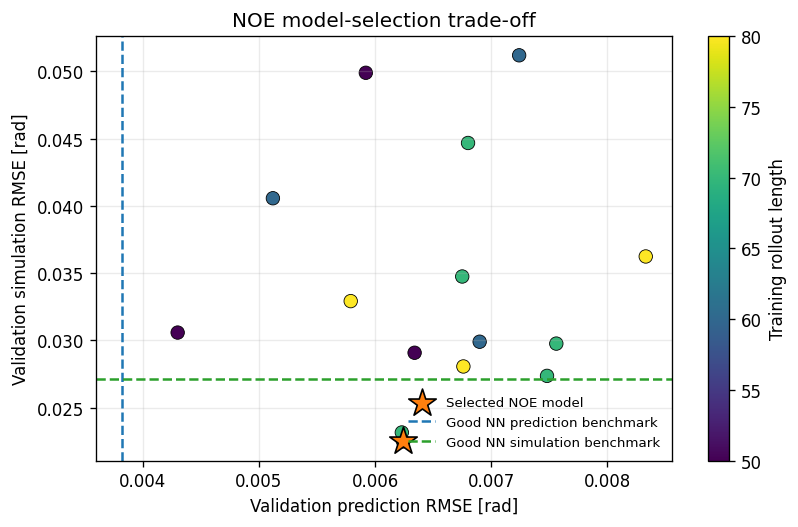

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Results copied from the completed NOE tuning sweep
prediction_rmse = np.array([
    0.00624, 0.00430, 0.00623, 0.00634, 0.00676,
    0.00579, 0.00748, 0.00690, 0.00756, 0.00512,
    0.00675, 0.00833, 0.00680, 0.00592, 0.00724
])

simulation_rmse = np.array([
    0.02249, 0.03058, 0.02315, 0.02908, 0.02806,
    0.03292, 0.02736, 0.02990, 0.02976, 0.04057,
    0.03475, 0.03624, 0.04468, 0.04990, 0.05120
])

rollout_length = np.array([
    70, 50, 70, 50, 80,
    80, 70, 60, 70, 60,
    70, 80, 70, 50, 60
])

fig, ax = plt.subplots(figsize=(7, 4.5))

points = ax.scatter(
    prediction_rmse,
    simulation_rmse,
    c=rollout_length,
    cmap="viridis",
    s=65,
    edgecolor="black",
    linewidth=0.5
)

# Selected combined model: first point
ax.scatter(
    prediction_rmse[0],
    simulation_rmse[0],
    marker="*",
    s=300,
    color="tab:orange",
    edgecolor="black",
    label="Selected NOE model",
    zorder=5
)

# Assignment benchmarks
ax.axvline(
    0.00382,
    color="tab:blue",
    linestyle="--",
    label="Good NN prediction benchmark"
)

ax.axhline(
    0.0271,
    color="tab:green",
    linestyle="--",
    label="Good NN simulation benchmark"
)

ax.set_xlabel("Validation prediction RMSE [rad]")
ax.set_ylabel("Validation simulation RMSE [rad]")
ax.set_title("NOE model-selection trade-off")
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=8)

colorbar = fig.colorbar(points, ax=ax)
colorbar.set_label("Training rollout length")

fig.tight_layout()
plt.show()

## 1.7 Retraining and saving the selected NOE checkpoints

In [16]:
import os

os.makedirs("saved_noe_models", exist_ok=True)

def train_and_evaluate_noe_choice(row, label, model_file):
    cfg = {
        "nfuture": int(row["nfuture"]),
        "na": int(row["na"]),
        "nb": int(row["nb"]),
        "hidden_size": int(row["hidden_size"]),
        "lr": float(row["lr"]),
        "weight_decay": float(row["weight_decay"]),
        "epochs": int(row["epochs"]),
    }

    print("\n====================================")
    print(label)
    print("Config:", cfg)
    print("====================================")

    np.random.seed(seed)
    torch.manual_seed(seed)

    U_train_choice, Y_train_choice = make_OE_data(
        u_train_n,
        th_train_n,
        nf=cfg["nfuture"]
    )
    U_val_choice, Y_val_choice = make_OE_data(
        u_val_n,
        th_val_n,
        nf=cfg["nfuture"]
    )

    U_train_choice_t = torch.tensor(U_train_choice, dtype=torch.float32)
    Y_train_choice_t = torch.tensor(Y_train_choice, dtype=torch.float32)
    U_val_choice_t = torch.tensor(U_val_choice, dtype=torch.float32)
    Y_val_choice_t = torch.tensor(Y_val_choice, dtype=torch.float32)

    train_dataset_choice = TensorDataset(U_train_choice_t, Y_train_choice_t)
    train_loader_choice = DataLoader(
        train_dataset_choice,
        batch_size=256,
        shuffle=True
    )

    model = NOENet(
        na=cfg["na"],
        nb=cfg["nb"],
        hidden_size=cfg["hidden_size"]
    )

    train_losses, val_losses = train_noe(
        model,
        train_loader_choice,
        U_val_choice_t,
        Y_val_choice_t,
        epochs=cfg["epochs"],
        lr=cfg["lr"],
        weight_decay=cfg["weight_decay"]
    )

    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "config": cfg,
            "label": label,
            "train_losses": train_losses,
            "val_losses": val_losses,
        },
        model_file
    )

    print("Saved model to:", model_file)

    th_val_pred, th_val_true_pred = one_step_prediction_noe(
        model,
        u_val_n,
        th_val_n,
        th_mean,
        th_std
    )

    th_val_sim, th_val_true = simulate_noe_full(
        model,
        u_val_n,
        th_val_n,
        th_mean,
        th_std
    )

    skip = model.n0

    pred_rms = np.sqrt(np.mean((th_val_pred[skip:] - th_val_true_pred[skip:])**2))
    pred_rms_deg = pred_rms / (2*np.pi) * 360
    pred_nrms = pred_rms / np.std(th_val_true_pred[skip:])

    sim_rms = np.sqrt(np.mean((th_val_sim[skip:] - th_val_true[skip:])**2))
    sim_rms_deg = sim_rms / (2*np.pi) * 360
    sim_nrms = sim_rms / np.std(th_val_true[skip:])

    combined_score = pred_rms / 0.00665 + sim_rms / 0.0271

    print("One-step prediction RMS:", pred_rms, "rad")
    print("One-step prediction RMS:", pred_rms_deg, "deg")
    print("One-step prediction NRMS:", pred_nrms * 100, "%")
    print("Full simulation RMS:", sim_rms, "rad")
    print("Full simulation RMS:", sim_rms_deg, "deg")
    print("Full simulation NRMS:", sim_nrms * 100, "%")
    print("Combined score:", combined_score)

    return {
        "label": label,
        "config": cfg,
        "model_file": model_file,
        "model": model,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "th_val_pred": th_val_pred,
        "th_val_true_pred": th_val_true_pred,
        "th_val_sim": th_val_sim,
        "th_val_true": th_val_true,
        "skip": skip,
        "pred_rms": pred_rms,
        "sim_rms": sim_rms,
        "combined_score": combined_score,
    }

In [17]:
best_combined_eval = train_and_evaluate_noe_choice(
    best_combined,
    "Best combined NOE model",
    "saved_noe_models/best_combined_noe.pt"
)

best_prediction_eval = train_and_evaluate_noe_choice(
    best_prediction,
    "Best one-step prediction NOE model",
    "saved_noe_models/best_prediction_noe.pt"
)


Best combined NOE model
Config: {'nfuture': 70, 'na': 5, 'nb': 4, 'hidden_size': 32, 'lr': 0.0003, 'weight_decay': 1e-06, 'epochs': 500}
Epoch    0 | train sim loss = 0.747286 | val sim loss = 0.770009 | lr = 3.00e-04
Epoch   10 | train sim loss = 0.017891 | val sim loss = 0.043369 | lr = 3.00e-04
Epoch   20 | train sim loss = 0.008309 | val sim loss = 0.026032 | lr = 3.00e-04
Epoch   30 | train sim loss = 0.004090 | val sim loss = 0.015093 | lr = 3.00e-04
Epoch   40 | train sim loss = 0.002877 | val sim loss = 0.010500 | lr = 3.00e-04
Epoch   50 | train sim loss = 0.002309 | val sim loss = 0.007844 | lr = 3.00e-04
Epoch   60 | train sim loss = 0.002059 | val sim loss = 0.006790 | lr = 3.00e-04
Epoch   70 | train sim loss = 0.001918 | val sim loss = 0.006460 | lr = 3.00e-04
Epoch   80 | train sim loss = 0.001779 | val sim loss = 0.006335 | lr = 3.00e-04
Epoch   90 | train sim loss = 0.001690 | val sim loss = 0.005728 | lr = 3.00e-04
Epoch  100 | train sim loss = 0.001593 | val sim los

### Optional checkpoint reload

This cell restores the saved selected models and recreates the validation
arrays without repeating the expensive training run.

In [12]:
from pathlib import Path

MODEL_DIR = Path(
    r"C:\Users\Vasil\5SC28 MACHINE LEARNING"
    r"\ML-for-control-systems-Pendulum-NOE-kostas"
    r"\saved_noe_models"
)

def load_saved_noe(filename, label):
    path = MODEL_DIR / filename

    try:
        checkpoint = torch.load(
            path,
            map_location="cpu",
            weights_only=False
        )
    except TypeError:
        checkpoint = torch.load(path, map_location="cpu")

    cfg = checkpoint["config"]

    model = NOENet(
        na=cfg["na"],
        nb=cfg["nb"],
        hidden_size=cfg["hidden_size"]
    )

    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    # Recreate validation prediction and simulation without training
    th_pred, th_true_pred = one_step_prediction_noe(
        model, u_val_n, th_val_n, th_mean, th_std
    )

    th_sim, th_true = simulate_noe_full(
        model, u_val_n, th_val_n, th_mean, th_std
    )

    skip = model.n0
    pred_rms = np.sqrt(np.mean(
        (th_pred[skip:] - th_true_pred[skip:])**2
    ))
    sim_rms = np.sqrt(np.mean(
        (th_sim[skip:] - th_true[skip:])**2
    ))

    print(label)
    print("Configuration:", cfg)
    print(f"Validation prediction RMSE: {pred_rms:.6f} rad")
    print(f"Validation simulation RMSE: {sim_rms:.6f} rad")

    return {
        "label": label,
        "config": cfg,
        "model": model,
        "train_losses": checkpoint["train_losses"],
        "val_losses": checkpoint["val_losses"],
        "th_val_pred": th_pred,
        "th_val_true_pred": th_true_pred,
        "th_val_sim": th_sim,
        "th_val_true": th_true,
        "skip": skip,
        "pred_rms": pred_rms,
        "sim_rms": sim_rms
    }


best_combined_eval = load_saved_noe(
    "best_combined_noe.pt",
    "Best combined NOE model"
)

best_prediction_eval = load_saved_noe(
    "best_prediction_noe.pt",
    "Best prediction NOE model"
)

print("\nSaved models loaded successfully. No training was executed.")

Best combined NOE model
Configuration: {'nfuture': 70, 'na': 5, 'nb': 4, 'hidden_size': 32, 'lr': 0.0003, 'weight_decay': 1e-06, 'epochs': 500}
Validation prediction RMSE: 0.006240 rad
Validation simulation RMSE: 0.022490 rad
Best prediction NOE model
Configuration: {'nfuture': 50, 'na': 4, 'nb': 3, 'hidden_size': 32, 'lr': 0.0003, 'weight_decay': 1e-06, 'epochs': 400}
Validation prediction RMSE: 0.004300 rad
Validation simulation RMSE: 0.030581 rad

Saved models loaded successfully. No training was executed.


## 1.8 Training history and validation results

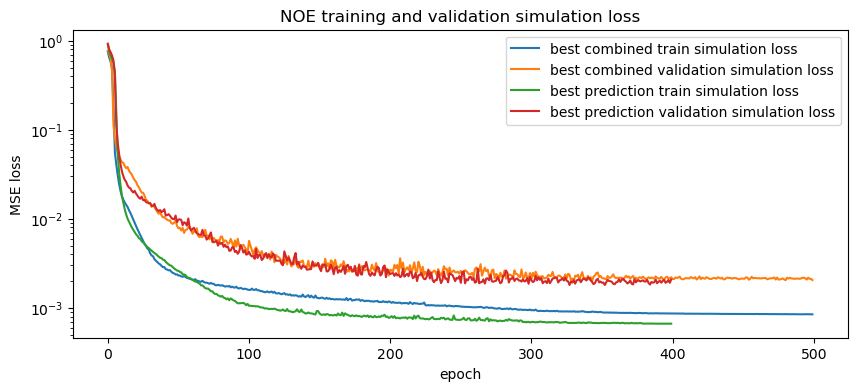

In [18]:
plt.figure(figsize=(10, 4))

plt.plot(
    best_combined_eval["train_losses"],
    label="best combined train simulation loss"
)
plt.plot(
    best_combined_eval["val_losses"],
    label="best combined validation simulation loss"
)

plt.plot(
    best_prediction_eval["train_losses"],
    label="best prediction train simulation loss"
)
plt.plot(
    best_prediction_eval["val_losses"],
    label="best prediction validation simulation loss"
)

plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("MSE loss")
plt.title("NOE training and validation simulation loss")
plt.legend()
plt.show()

### Representative short validation rollout

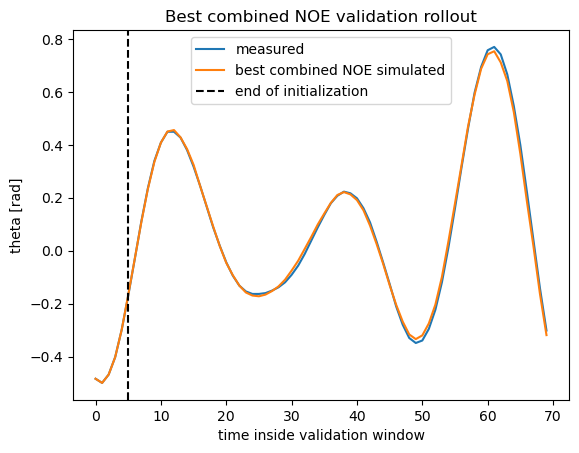

Best combined validation rollout RMS: 0.013439581 rad
Best combined validation rollout RMS: 0.7700312581590063 deg
Best combined validation rollout NRMS: 4.585207253694534 %


In [20]:
final_noe_model = best_combined_eval["model"]
final_noe_model.eval()

cfg = best_combined_eval["config"]
nfuture = cfg["nfuture"]

U_val_combined, Y_val_combined = make_OE_data(
    u_val_n,
    th_val_n,
    nf=nfuture
)

U_val_combined_t = torch.tensor(U_val_combined, dtype=torch.float32)
Y_val_combined_t = torch.tensor(Y_val_combined, dtype=torch.float32)

with torch.no_grad():
    Y_val_hat = final_noe_model(
        U_val_combined_t[:1],
        Y_val_combined_t[:1]
    ).numpy()

Y_true = Y_val_combined_t[:1].numpy()

# denormalize
Y_hat_denorm = Y_val_hat[0] * th_std + th_mean
Y_true_denorm = Y_true[0] * th_std + th_mean

plt.figure()
plt.plot(Y_true_denorm, label="measured")
plt.plot(Y_hat_denorm, label="best combined NOE simulated")
plt.axvline(
    final_noe_model.n0,
    color="black",
    linestyle="--",
    label="end of initialization"
)
plt.xlabel("time inside validation window")
plt.ylabel("theta [rad]")
plt.title("Best combined NOE validation rollout")
plt.legend()
plt.show()

rms_window = np.sqrt(
    np.mean(
        (Y_hat_denorm[final_noe_model.n0:] - Y_true_denorm[final_noe_model.n0:])**2
    )
)
rms_window_deg = rms_window / (2*np.pi) * 360
nrms_window = rms_window / np.std(Y_true_denorm[final_noe_model.n0:])

print("Best combined validation rollout RMS:", rms_window, "rad")
print("Best combined validation rollout RMS:", rms_window_deg, "deg")
print("Best combined validation rollout NRMS:", nrms_window * 100, "%")

### Full free-run validation simulation

Best combined full validation simulation RMS: 0.02248972629555716 rad
Best combined full validation simulation RMS: 1.2885663991398126 deg
Best combined full validation simulation NRMS: 4.569201734806911 %


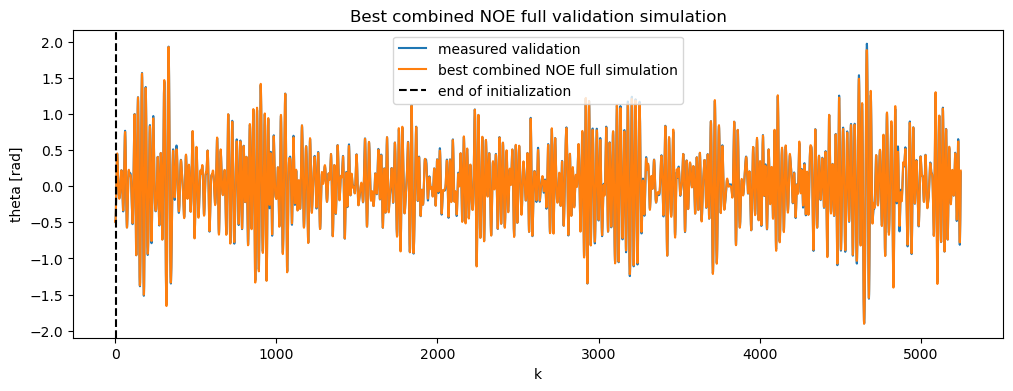

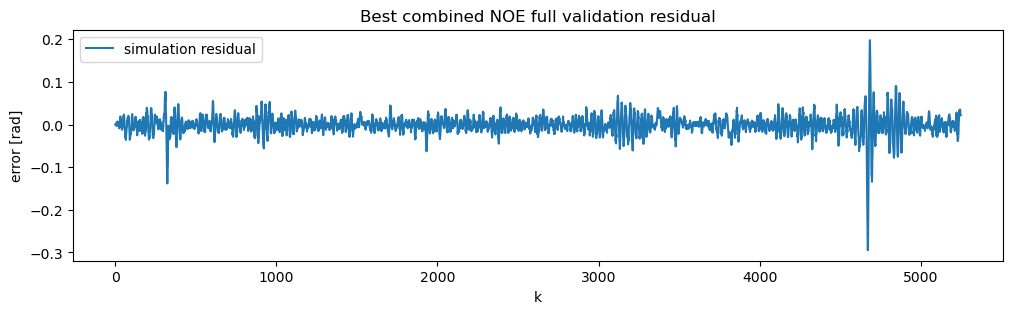

In [21]:
final_noe_model = best_combined_eval["model"]
final_noe_model.eval()

th_val_sim, th_val_true = simulate_noe_full(
    final_noe_model,
    u_val_n,
    th_val_n,
    th_mean,
    th_std
)

skip = final_noe_model.n0

rms = np.sqrt(np.mean((th_val_sim[skip:] - th_val_true[skip:])**2))
rms_deg = rms / (2*np.pi) * 360
nrms = rms / np.std(th_val_true[skip:])

print("Best combined full validation simulation RMS:", rms, "rad")
print("Best combined full validation simulation RMS:", rms_deg, "deg")
print("Best combined full validation simulation NRMS:", nrms * 100, "%")

plt.figure(figsize=(12, 4))
plt.plot(th_val_true, label="measured validation")
plt.plot(th_val_sim, label="best combined NOE full simulation")
plt.axvline(skip, color="black", linestyle="--", label="end of initialization")
plt.xlabel("k")
plt.ylabel("theta [rad]")
plt.title("Best combined NOE full validation simulation")
plt.legend()
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(th_val_sim - th_val_true, label="simulation residual")
plt.xlabel("k")
plt.ylabel("error [rad]")
plt.title("Best combined NOE full validation residual")
plt.legend()
plt.show()

### One-step-ahead validation prediction

Best combined validation one-step prediction RMS: 0.0062395140388512085 rad
Best combined validation one-step prediction RMS: 0.35749782063880065 deg
Best combined validation one-step prediction NRMS: 1.2676720915142075 %


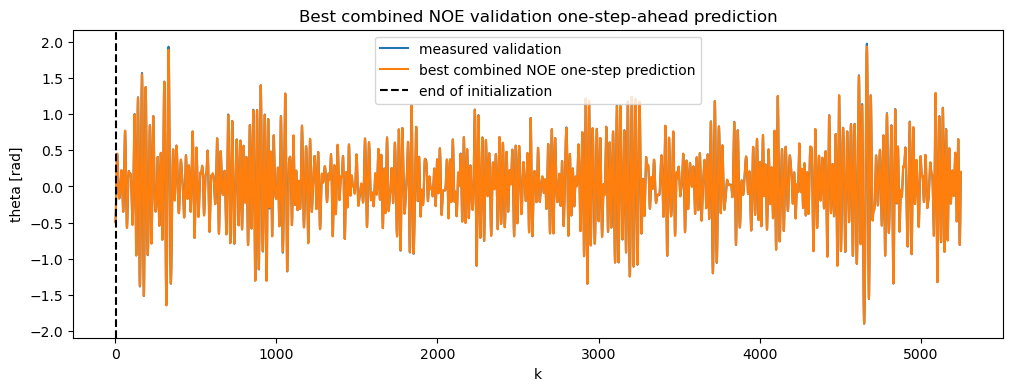

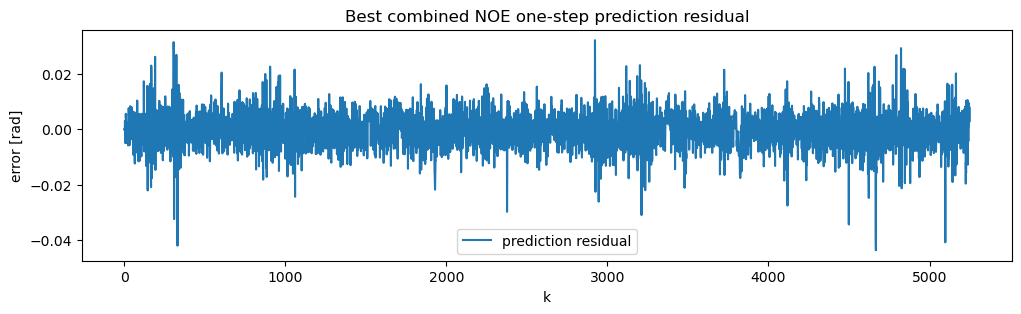

In [22]:
final_noe_model = best_combined_eval["model"]
final_noe_model.eval()

th_val_pred, th_val_true_pred = one_step_prediction_noe(
    final_noe_model,
    u_val_n,
    th_val_n,
    th_mean,
    th_std
)

skip = final_noe_model.n0

pred_rms = np.sqrt(np.mean((th_val_pred[skip:] - th_val_true_pred[skip:])**2))
pred_rms_deg = pred_rms / (2*np.pi) * 360
pred_nrms = pred_rms / np.std(th_val_true_pred[skip:])

print("Best combined validation one-step prediction RMS:", pred_rms, "rad")
print("Best combined validation one-step prediction RMS:", pred_rms_deg, "deg")
print("Best combined validation one-step prediction NRMS:", pred_nrms * 100, "%")

plt.figure(figsize=(12, 4))
plt.plot(th_val_true_pred, label="measured validation")
plt.plot(th_val_pred, label="best combined NOE one-step prediction")
plt.axvline(skip, color="black", linestyle="--", label="end of initialization")
plt.xlabel("k")
plt.ylabel("theta [rad]")
plt.title("Best combined NOE validation one-step-ahead prediction")
plt.legend()
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(th_val_pred - th_val_true_pred, label="prediction residual")
plt.xlabel("k")
plt.ylabel("error [rad]")
plt.title("Best combined NOE one-step prediction residual")
plt.legend()
plt.show()

# 2. Benchmark-Aligned Encoder RNN

The previous encoder-RNN experiments and their non-reproducible outputs were
removed. The retained model uses 15 measured input-output samples to initialize
the hidden state and is shifted so that information available up to time
$k-1$ predicts the angle at time $k$. This makes the same checkpoint compatible
with the official one-step prediction and free-run simulation formats.

## 2.1 Encoder-RNN architecture

In [12]:
class simple_encoder_RNN(nn.Module):
    def __init__(self, hidden_size, n_encoder=20):
        super(simple_encoder_RNN, self).__init__()

        self.hidden_size = hidden_size
        self.input_size = 1
        self.output_size = 1
        self.n_encoder = n_encoder

        net = lambda n_in, n_out: nn.Sequential(
            nn.Linear(n_in, 40),
            nn.Sigmoid(),
            nn.Linear(40, n_out)
        ).double()

        self.h2h = net(self.input_size + hidden_size, self.hidden_size)
        self.h2o = net(self.input_size + hidden_size, self.output_size)
        self.encoder = net(n_encoder * 2, hidden_size)

    def forward(self, inputs, hist):
        hidden = self.encoder(hist)

        outputs = []

        for i in range(inputs.shape[1]):
            input_i = inputs[:, i]
            combined = torch.cat((hidden, input_i[:, None]), dim=1)

            outputs.append(self.h2o(combined)[:, 0])

            hidden = self.h2h(combined)

        return torch.stack(outputs, dim=1)

## 2.2 Benchmark-aligned training

The following completed run is the retained RNN training. It does not overwrite
the previous checkpoint and saves the selected state as
`best_encoder_rnn_aligned.pt`.

In [17]:
# Benchmark-aligned RNN training only

import copy
from torch.utils.data import TensorDataset, DataLoader

n_encode = 15
n_future = 150
hidden_size = 16
batch_size = 512
epochs = 300
patience = 40

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


def make_aligned_data(u, y, n_encode, n_future):
    histories, inputs, targets = [], [], []

    for k in range(n_encode, len(y) - n_future + 1):
        # Information available up to k-1
        history = np.concatenate([
            u[k-n_encode:k],
            y[k-n_encode:k]
        ])

        # u[k-1] predicts y[k]
        input_sequence = u[k-1:k+n_future-1]
        target_sequence = y[k:k+n_future]

        histories.append(history)
        inputs.append(input_sequence)
        targets.append(target_sequence)

    return (
        torch.tensor(np.array(histories), dtype=torch.float64),
        torch.tensor(np.array(inputs), dtype=torch.float64),
        torch.tensor(np.array(targets), dtype=torch.float64)
    )


hist_train, U_train, Y_train = make_aligned_data(
    u_train_n, th_train_n, n_encode, n_future
)

hist_val, U_val, Y_val = make_aligned_data(
    u_val_n, th_val_n, n_encode, n_future
)

train_loader = DataLoader(
    TensorDataset(hist_train, U_train, Y_train),
    batch_size=batch_size,
    shuffle=True
)

model_rnn_aligned = simple_encoder_RNN(
    hidden_size=hidden_size,
    n_encoder=n_encode
).to(device)

optimizer = torch.optim.Adam(
    model_rnn_aligned.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    factor=0.5,
    patience=15,
    min_lr=1e-5
)

best_val_loss = np.inf
best_state = None
best_epoch = 0
epochs_without_improvement = 0

for epoch in range(epochs):
    model_rnn_aligned.train()
    batch_losses = []

    for history, inputs, targets in train_loader:
        history = history.to(device)
        inputs = inputs.to(device)
        targets = targets.to(device)

        prediction = model_rnn_aligned(inputs, history)
        loss = torch.mean((prediction - targets) ** 2)

        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model_rnn_aligned.parameters(),
            max_norm=1.0
        )

        optimizer.step()
        batch_losses.append(loss.item())

    train_loss = np.mean(batch_losses)

    model_rnn_aligned.eval()

    with torch.no_grad():
        val_prediction = model_rnn_aligned(
            U_val.to(device),
            hist_val.to(device)
        )

        val_loss = torch.mean(
            (val_prediction - Y_val.to(device)) ** 2
        ).item()

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        best_state = copy.deepcopy(
            model_rnn_aligned.state_dict()
        )
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch:3d} | "
            f"train MSE = {train_loss:.6f} | "
            f"val MSE = {val_loss:.6f}"
        )

    if epochs_without_improvement >= patience:
        print("Early stopping at epoch:", epoch)
        break


model_rnn_aligned.load_state_dict(best_state)

torch.save(
    {
        "model_state_dict": best_state,
        "config": {
            "n_encode": n_encode,
            "n_future": n_future,
            "hidden_size": hidden_size,
            "epochs": epochs,
            "batch_size": batch_size,
            "lr": 1e-3,
            "weight_decay": 1e-5
        },
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss
    },
    "best_encoder_rnn_aligned.pt"
)

print("\nTraining completed")
print("Best epoch:", best_epoch)
print("Best validation MSE:", best_val_loss)
print("Saved: best_encoder_rnn_aligned.pt")

Device: cuda
Epoch   0 | train MSE = 1.000359 | val MSE = 1.101429
Epoch  10 | train MSE = 0.134396 | val MSE = 0.177979
Epoch  20 | train MSE = 0.094972 | val MSE = 0.147257
Epoch  30 | train MSE = 0.088165 | val MSE = 0.136618
Epoch  40 | train MSE = 0.083543 | val MSE = 0.136270
Epoch  50 | train MSE = 0.079236 | val MSE = 0.125986
Epoch  60 | train MSE = 0.076356 | val MSE = 0.121503
Epoch  70 | train MSE = 0.072930 | val MSE = 0.115741
Epoch  80 | train MSE = 0.070762 | val MSE = 0.108125
Epoch  90 | train MSE = 0.067295 | val MSE = 0.104649
Epoch 100 | train MSE = 0.062965 | val MSE = 0.096796
Epoch 110 | train MSE = 0.056414 | val MSE = 0.092787
Epoch 120 | train MSE = 0.058920 | val MSE = 0.073637
Epoch 130 | train MSE = 0.031989 | val MSE = 0.036433
Epoch 140 | train MSE = 0.023548 | val MSE = 0.046110
Epoch 150 | train MSE = 0.017397 | val MSE = 0.031847
Epoch 160 | train MSE = 0.008210 | val MSE = 0.023839
Epoch 170 | train MSE = 0.010239 | val MSE = 0.028827
Epoch 180 | tra

### Reload the selected aligned-RNN checkpoint without retraining

Run this cell after a kernel restart to restore the final aligned model. It is
the RNN counterpart of the NOE checkpoint-reload cell.

In [13]:
from pathlib import Path

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

rnn_checkpoint_path = Path(PROJECT_DIR) / "best_encoder_rnn_aligned.pt"

try:
    rnn_checkpoint = torch.load(
        rnn_checkpoint_path,
        map_location=device,
        weights_only=False
    )
except TypeError:
    rnn_checkpoint = torch.load(
        rnn_checkpoint_path,
        map_location=device
    )

rnn_config = rnn_checkpoint["config"]
n_encode = int(rnn_config["n_encode"])
n_future = int(rnn_config["n_future"])
hidden_size = int(rnn_config["hidden_size"])

model_rnn_aligned = simple_encoder_RNN(
    hidden_size=hidden_size,
    n_encoder=n_encode
).to(device)

model_rnn_aligned.load_state_dict(
    rnn_checkpoint["model_state_dict"]
)
model_rnn_aligned.eval()

print("Loaded aligned RNN checkpoint:", rnn_checkpoint_path)
print("Configuration:", rnn_config)
print("Best epoch:", rnn_checkpoint["best_epoch"])
print("Best validation MSE:", rnn_checkpoint["best_val_loss"])

Loaded aligned RNN checkpoint: C:\Users\Vasil\5SC28 MACHINE LEARNING\ML-for-control-systems-Pendulum-NOE-kostas\best_encoder_rnn_aligned.pt
Configuration: {'n_encode': 15, 'n_future': 150, 'hidden_size': 16, 'epochs': 300, 'batch_size': 512, 'lr': 0.001, 'weight_decay': 1e-05}
Best epoch: 299
Best validation MSE: 0.016005172066592202


## 2.3 Validation prediction, simulation, and residuals

In [14]:
model_rnn_aligned.eval()

# One-step prediction
histories = []
inputs = []

for k in range(n_encode, len(u_val_n)):
    histories.append(np.concatenate([
        u_val_n[k-n_encode:k],
        th_val_n[k-n_encode:k]
    ]))

    inputs.append([u_val_n[k-1]])

histories = torch.tensor(
    np.array(histories),
    dtype=torch.float64,
    device=device
)

inputs = torch.tensor(
    np.array(inputs),
    dtype=torch.float64,
    device=device
)

with torch.no_grad():
    prediction_n = model_rnn_aligned(
        inputs, histories
    )[:, 0].cpu().numpy()

prediction = prediction_n * th_std + th_mean
prediction_true = (
    th_val_n[n_encode:] * th_std + th_mean
)

prediction_rmse = np.sqrt(
    np.mean((prediction - prediction_true) ** 2)
)


# Full free-run simulation
initial_history = np.concatenate([
    u_val_n[:n_encode],
    th_val_n[:n_encode]
])[None, :]

simulation_inputs = u_val_n[n_encode-1:-1][None, :]

with torch.no_grad():
    simulation_n = model_rnn_aligned(
        torch.tensor(
            simulation_inputs,
            dtype=torch.float64,
            device=device
        ),
        torch.tensor(
            initial_history,
            dtype=torch.float64,
            device=device
        )
    )[0].cpu().numpy()

simulation = simulation_n * th_std + th_mean
simulation_true = (
    th_val_n[n_encode:] * th_std + th_mean
)

simulation_rmse = np.sqrt(
    np.mean((simulation - simulation_true) ** 2)
)

print("Aligned RNN validation results")
print("--------------------------------")
print(f"Prediction RMSE: {prediction_rmse:.6f} rad")
print(f"Prediction RMSE: {np.degrees(prediction_rmse):.3f} deg")
print(f"Simulation RMSE: {simulation_rmse:.6f} rad")
print(f"Simulation RMSE: {np.degrees(simulation_rmse):.3f} deg")

Aligned RNN validation results
--------------------------------
Prediction RMSE: 0.019195 rad
Prediction RMSE: 1.100 deg
Simulation RMSE: 0.063686 rad
Simulation RMSE: 3.649 deg


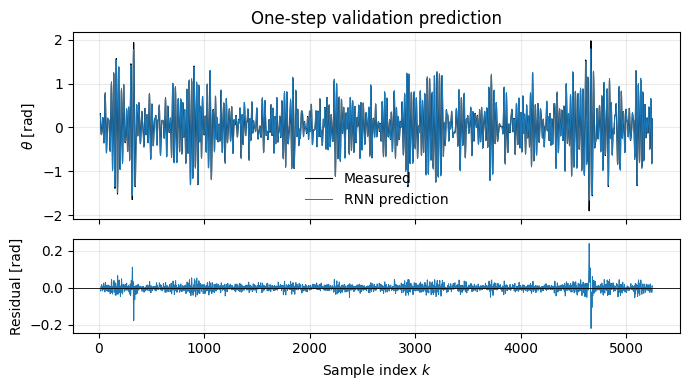

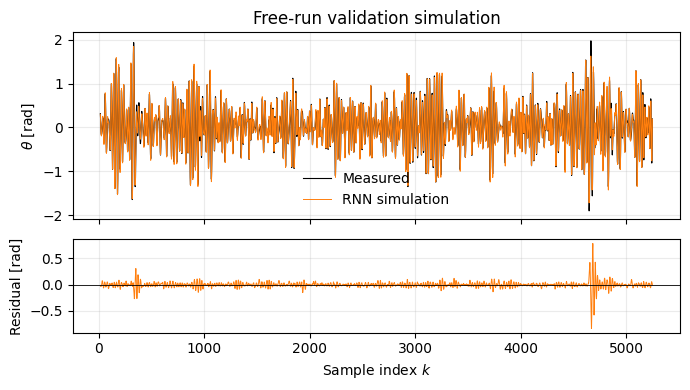

Saved: C:\Users\Vasil\5SC28 MACHINE LEARNING\ML-for-control-systems-Pendulum-NOE-kostas\graphs\EncoderRNN_prediction.png
Saved: C:\Users\Vasil\5SC28 MACHINE LEARNING\ML-for-control-systems-Pendulum-NOE-kostas\graphs\EncoderRNN_simulation.png


In [16]:
# Create separate prediction and simulation figures for the report.
from pathlib import Path

k_eval = np.arange(n_encode, len(u_val_n))
prediction_residual = prediction - prediction_true
simulation_residual = simulation - simulation_true

graphs_dir = Path(PROJECT_DIR) / "graphs"
graphs_dir.mkdir(exist_ok=True)

# One-step prediction and residual
fig_pred, ax_pred = plt.subplots(
    2, 1,
    figsize=(7, 4),
    sharex=True,
    gridspec_kw={"height_ratios": [2.0, 1.0]}
)

ax_pred[0].plot(
    k_eval, prediction_true,
    color="black", linewidth=0.8, label="Measured"
)
ax_pred[0].plot(
    k_eval, prediction,
    color="tab:blue", linewidth=0.7, label="RNN prediction"
)
ax_pred[0].set_title("One-step validation prediction")
ax_pred[0].set_ylabel(r"$\theta$ [rad]")
ax_pred[0].legend(frameon=False)

ax_pred[1].plot(
    k_eval, prediction_residual,
    color="tab:blue", linewidth=0.7
)
ax_pred[1].axhline(0.0, color="black", linewidth=0.6)
ax_pred[1].set_xlabel("Sample index $k$")
ax_pred[1].set_ylabel("Residual [rad]")

for axis in ax_pred:
    axis.grid(True, alpha=0.25)

fig_pred.tight_layout()
prediction_path = graphs_dir / "EncoderRNN_prediction.png"
fig_pred.savefig(prediction_path, dpi=300, bbox_inches="tight")
plt.show()


# Free-run simulation and residual
fig_sim, ax_sim = plt.subplots(
    2, 1,
    figsize=(7, 4),
    sharex=True,
    gridspec_kw={"height_ratios": [2.0, 1.0]}
)

ax_sim[0].plot(
    k_eval, simulation_true,
    color="black", linewidth=0.8, label="Measured"
)
ax_sim[0].plot(
    k_eval, simulation,
    color="tab:orange", linewidth=0.7, label="RNN simulation"
)
ax_sim[0].set_title("Free-run validation simulation")
ax_sim[0].set_ylabel(r"$\theta$ [rad]")
ax_sim[0].legend(frameon=False)

ax_sim[1].plot(
    k_eval, simulation_residual,
    color="tab:orange", linewidth=0.7
)
ax_sim[1].axhline(0.0, color="black", linewidth=0.6)
ax_sim[1].set_xlabel("Sample index $k$")
ax_sim[1].set_ylabel("Residual [rad]")

for axis in ax_sim:
    axis.grid(True, alpha=0.25)

fig_sim.tight_layout()
simulation_path = graphs_dir / "EncoderRNN_simulation.png"
fig_sim.savefig(simulation_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", prediction_path)
print("Saved:", simulation_path)

## 2.4 Hidden-test submission files

In [19]:
from pathlib import Path

benchmark_dir = Path(
    r"C:\Users\Vasil\5SC28 MACHINE LEARNING"
    r"\gym-unbalanced-disk\disc-benchmark-files"
)

submission_dir = Path(
    r"C:\Users\Vasil\5SC28 MACHINE LEARNING"
    r"\ML-for-control-systems-Pendulum-NOE-kostas"
    r"\submission_files"
)

submission_dir.mkdir(exist_ok=True)

model_rnn_aligned.eval()


# ============================================================
# 1. Hidden-test one-step prediction submission
# ============================================================

prediction_template = np.load(
    benchmark_dir /
    "hidden-test-prediction-submission-file.npz"
)

upast = prediction_template["upast"].copy()
thpast = prediction_template["thpast"].copy()

# Normalize all 15 available history samples
upast_n = (upast - u_mean) / u_std
thpast_n = (thpast - th_mean) / th_std

prediction_history = np.concatenate(
    (upast_n, thpast_n),
    axis=1
)

# u[k-1] is the final available input
prediction_input = upast_n[:, -1:]

with torch.no_grad():
    thnow_n = model_rnn_aligned(
        torch.tensor(
            prediction_input,
            dtype=torch.float64,
            device=device
        ),
        torch.tensor(
            prediction_history,
            dtype=torch.float64,
            device=device
        )
    )[:, 0].cpu().numpy()

thnow = thnow_n * th_std + th_mean

prediction_file = (
    submission_dir /
    "EncoderRNN_hidden-test-prediction-submission.npz"
)

np.savez(
    prediction_file,
    upast=upast,
    thpast=thpast,
    thnow=thnow
)


# ============================================================
# 2. Hidden-test free-run simulation submission
# ============================================================

simulation_template = np.load(
    benchmark_dir /
    "hidden-test-simulation-submission-file.npz"
)

u_hidden = simulation_template["u"].copy()
th_hidden = simulation_template["th"].copy()

first_prediction = 50

# Use the final 15 measured samples before the unknown section
u_history_n = (
    u_hidden[first_prediction-n_encode:first_prediction]
    - u_mean
) / u_std

th_history_n = (
    th_hidden[first_prediction-n_encode:first_prediction]
    - th_mean
) / th_std

simulation_history = np.concatenate(
    (u_history_n, th_history_n)
)[None, :]

# u[49] predicts theta[50], ..., u[4998] predicts theta[4999]
simulation_inputs_n = (
    u_hidden[first_prediction-1:-1] - u_mean
) / u_std

with torch.no_grad():
    simulation_prediction_n = model_rnn_aligned(
        torch.tensor(
            simulation_inputs_n[None, :],
            dtype=torch.float64,
            device=device
        ),
        torch.tensor(
            simulation_history,
            dtype=torch.float64,
            device=device
        )
    )[0].cpu().numpy()

th_hidden[first_prediction:] = (
    simulation_prediction_n * th_std + th_mean
)

simulation_file = (
    submission_dir /
    "EncoderRNN_hidden-test-simulation-submission.npz"
)

np.savez(
    simulation_file,
    u=u_hidden,
    th=th_hidden
)


print("Created:")
print(prediction_file)
print(simulation_file)

print("\nPrediction shape:", thnow.shape)
print("Simulation shape:", th_hidden.shape)
print("Finite prediction:", np.all(np.isfinite(thnow)))
print("Finite simulation:", np.all(np.isfinite(th_hidden)))

Created:
C:\Users\Vasil\5SC28 MACHINE LEARNING\ML-for-control-systems-Pendulum-NOE-kostas\submission_files\EncoderRNN_hidden-test-prediction-submission.npz
C:\Users\Vasil\5SC28 MACHINE LEARNING\ML-for-control-systems-Pendulum-NOE-kostas\submission_files\EncoderRNN_hidden-test-simulation-submission.npz

Prediction shape: (645,)
Simulation shape: (5000,)
Finite prediction: True
Finite simulation: True
